# Data Cleaning and Chunking

Transform the structured JSONL data from Stage 2 into a set of semantically rich, context-aware chunks for vector embedding. 

### Objectives
1. **Character Normalization**: Standardize symbols and quotes for consistent indexing.
2. **Noise Filtering**: Remove "page furniture" (headers/footers) and insignificant text segments.
3. **Context Propagation**: Link narrative text to governing Article, Division, and Section titles.
4. **Semantic Chunking**: Split long documents into overlapping segments for RAG retrieval.
5. **Data Profiling**: Verify chunk length distribution and export the final dataset.

## 1. Setup

Import necessary libraries for data manipulation, regular expressions, and visualization. Define paths for input structured data and final chunked output.

In [26]:
import pandas as pd
import numpy as np
import json
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Input and Output Paths
DATA_PATH = Path('../data/processed/san_diego_code_structured.jsonl')
OUTPUT_PATH = Path('../data/processed/san_diego_code_chunks.jsonl')

# Load data
df = pd.read_json(DATA_PATH, lines=True)

# Calculate text length for filtering
df['text_length'] = df['text'].str.len()

print(f"Loaded {len(df)} records.")
df.head()

Loaded 64639 records.


,chapter,filename,element_type,text,text_length
0,chapter_11,Ch11Art03Division02.pdf,Header,San Diego Municipal Code (10-2024),34
1,chapter_11,Ch11Art03Division02.pdf,Header,Chapter 11: Land Development Procedures,39
2,chapter_11,Ch11Art03Division02.pdf,Title,Article 3: Land Development Procedures,38
3,chapter_11,Ch11Art03Division02.pdf,Text,Division 2: Rules for Calculation and Measurem...,104
4,chapter_11,Ch11Art03Division02.pdf,Text,§113.0201,9


## 2. Basic Cleaning

### 2.1 Character Normalization

Normalize "smart" quotes, long dashes, and non-standard typography into standard ASCII equivalents to prevent issues during embedding and retrieval.

In [27]:
def normalize_chars(text):
    """Standardize non-standard characters like smart quotes and dashes."""
    if not isinstance(text, str):
        return text
    
    norm_map = {
        "“": '"',
        "”": '"',
        "‘": "'",
        "’": "'",
        "–": "-",
        "—": "-"
    }
    
    for char, replacement in norm_map.items():
        text = text.replace(char, replacement)
    return text

df['text'] = df['text'].apply(normalize_chars)
print("Character normalization complete.")

Character normalization complete.


### 2.2 Noise Filtering

Remove recursive headers, footers, and "noise floor" records (e.g., single characters or empty lines) which lack semantic value for the RAG system.

In [28]:
# Filter out Headers, Footers, and single-character noise
df_clean = df[
    (~df['element_type'].isin(['Header', 'Footer'])) & (df['text_length'] > 1)
].copy()

print(f"Rows after filtering: {len(df_clean)} (Removed {len(df) - len(df_clean)} noise records)")

Rows after filtering: 51965 (Removed 12674 noise records)


## 3. Structural Analysis & Extraction

### 3.1 Citation Extraction

Extract municipal code citations (e.g., `121.0101`) using regex. Store these as metadata to enable direct reference matching during retrieval.

In [29]:
CITATION_REGEX = r'\b\d{2,3}\.\d{4}\b'

def extract_citations(text):
    """Extract municipal code citations using regex."""
    return re.findall(CITATION_REGEX, text)

df_clean['citations'] = df_clean['text'].apply(extract_citations)
df_clean.head()

,chapter,filename,element_type,text,text_length,citations
2,chapter_11,Ch11Art03Division02.pdf,Title,Article 3: Land Development Procedures,38,[]
3,chapter_11,Ch11Art03Division02.pdf,Text,Division 2: Rules for Calculation and Measurem...,104,[]
4,chapter_11,Ch11Art03Division02.pdf,Text,§113.0201,9,[113.0201]
5,chapter_11,Ch11Art03Division02.pdf,Title,Purpose of Rules for Calculation and Measurement,48,[]
6,chapter_11,Ch11Art03Division02.pdf,NarrativeText,The purpose of this division is to clarify and...,394,[]


### 3.2 State-Based Context Propagation

Maintain context across paragraphs by linking narrative text to preceding titles. 

Use a **stateful crawler** to track the current Article, Division, and Section. Prepend this hierarchical context to each narrative text element.

In [30]:
def propagate_context(df):
    """Propagate hierarchical titles to subsequent narrative text elements."""
    current_article = ""
    current_division = ""
    current_section = ""
    
    results = []
    
    for idx, row in df.iterrows():
        text = row['text'].strip()
        etype = row['element_type']
        
        # Detect hierarchy updates
        if etype == 'Title':
            if re.match(r'^Article', text, re.I):
                current_article = text
                current_division = ""
                current_section = ""
            elif re.match(r'^Division', text, re.I):
                current_division = text
                current_section = ""
            else:
                current_section = text
        
        # Construct context prefix
        hierarchy_levels = [lvl for lvl in [current_article, current_division, current_section] if lvl]
        context_prefix = " > ".join(hierarchy_levels)
        
        # Prepend context to NarrativeText or ListItems
        if etype in ['NarrativeText', 'ListItem']:
            row['contextualized_text'] = f"{context_prefix}: {text}" if context_prefix else text
        else:
            row['contextualized_text'] = text
            
        row['hierarchy'] = {
            'article': current_article,
            'division': current_division,
            'section': current_section
        }
        results.append(row)
        
    return pd.DataFrame(results)

df_context = propagate_context(df_clean)
print("Context propagation complete.")
df_context[['element_type', 'contextualized_text']].head(10)

Context propagation complete.


,element_type,contextualized_text
2,Title,Article 3: Land Development Procedures
3,Text,Division 2: Rules for Calculation and Measurem...
4,Text,§113.0201
5,Title,Purpose of Rules for Calculation and Measurement
6,NarrativeText,Article 3: Land Development Procedures > Purpo...
7,Title,§113.0202 When Rules for Calculation and Measu...
8,NarrativeText,Article 3: Land Development Procedures > §113....
9,Title,Ch. Art. Div. 2 3 11
13,Title,Table 113-02A Rules for Calculation and Measur...
14,Title,Land Development Term or Concept


## 4. Semantic Chunking

Use LangChain's `RecursiveCharacterTextSplitter` to break long sections into smaller chunks. Employ an overlap buffer to preserve semantic meaning across chunk boundaries.

In [31]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=750,
    chunk_overlap=75,
    separators=["\n\n", "\n", ". ", " ", ""]
)

def split_records(df):
    """Split contextualized text into smaller chunks for embedding."""
    chunked_records = []
    for idx, row in df.iterrows():
        chunks = splitter.split_text(row['contextualized_text'])
        for i, chunk in enumerate(chunks):
            chunk_meta = {
                'chapter': row.get('chapter', ''),
                'filename': row.get('filename', ''),
                'hierarchy': row['hierarchy'],
                'citations': row['citations'],
                'chunk_index': i
            }
            chunked_records.append({
                'text': chunk,
                'metadata': chunk_meta,
                'source': row.get('filename', '')
            })
    return pd.DataFrame(chunked_records)

df_final = split_records(df_context)
print(f"Final chunk count: {len(df_final)}")

Final chunk count: 52384


## 5. Verification & Export

### 5.1 Chunk Length Distribution

Visualize chunk length distribution to ensure segments fit within the target window (approx. 750 characters) and verify the splitter performance.

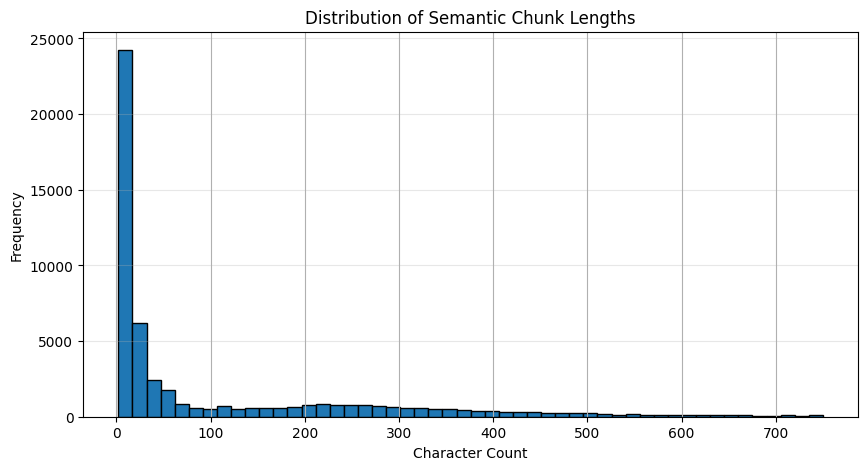

In [32]:
# Plot character lengths of final chunks
plt.figure(figsize=(10, 5))
df_final['text'].str.len().hist(bins=50, color='#1f77b4', edgecolor='black')

plt.title('Distribution of Semantic Chunk Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 5.2 Export

Save processed chunks to a JSONL file. This dataset serves as the input for the vector database ingestion stage.

In [33]:
df_final.to_json(OUTPUT_PATH, orient='records', lines=True)
print(f"Exported {len(df_final)} chunks to {OUTPUT_PATH}")

Exported 52384 chunks to ../data/processed/san_diego_code_chunks.jsonl
